In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

#preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , StratifiedKFold, cross_val_score

# Base models for the stacking ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier


# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

print('All libraries imported successfully.')


All libraries imported successfully.


## Step 1 — Load the Dataset

We load the Cleveland Heart Disease dataset (cleveland_heart_disease.csv).

- **297 rows**, **14 columns**
- 13 input features (age, sex, chest pain type, etc.)
- 1 target column: Heart_disease (0 = No Disease, 1 = Disease)

The .head() call shows the first 5 rows so we can visually confirm the data loaded correctly.

In [2]:
df = pd.read_csv('data/cleveland_heart_disease.csv')

print(f'Dataset shape: {df.shape}')  # (rows, columns)
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (297, 14)
Columns: ['Age', 'Sex', 'Chest_pain', 'Resting_blood_pressure', 'Cholesterol', 'Fasting_Blood_Sugar', 'ECG_results', 'Maximum_heart_rate', 'Exercise_induced_angina', 'ST_depression', 'ST_slope', 'Major_vessels', 'Thalassemia_types', 'Heart_disease']


,Age,Sex,Chest_pain,Resting_blood_pressure,Cholesterol,Fasting_Blood_Sugar,ECG_results,Maximum_heart_rate,Exercise_induced_angina,ST_depression,ST_slope,Major_vessels,Thalassemia_types,Heart_disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 2 — Data Quality Check

Before training any model, we must verify the data is clean.

**What we check:**
- **Missing values** — any NaN in a column would break training
- **Class distribution** — how many patients have heart disease vs. don't

**Result:** Zero missing values across all 14 columns. The dataset is balanced:
- 160 patients with **No Disease** (0)
- 137 patients with **Disease** (1)

The bar chart below visualises this balance.

In [3]:
print('Missing values per column:')
print(df.isnull().sum())
print()

print('Target class distribution:')
print(df['Heart_disease'].value_counts())
print()
print(f"Disease cases:    {df['Heart_disease'].sum()}")
print(f"No disease cases: {(df['Heart_disease'] == 0).sum()}")

Missing values per column:
Age                        0
Sex                        0
Chest_pain                 0
Resting_blood_pressure     0
Cholesterol                0
Fasting_Blood_Sugar        0
ECG_results                0
Maximum_heart_rate         0
Exercise_induced_angina    0
ST_depression              0
ST_slope                   0
Major_vessels              0
Thalassemia_types          0
Heart_disease              0
dtype: int64

Target class distribution:
Heart_disease
0    160
1    137
Name: count, dtype: int64

Disease cases:    137
No disease cases: 160


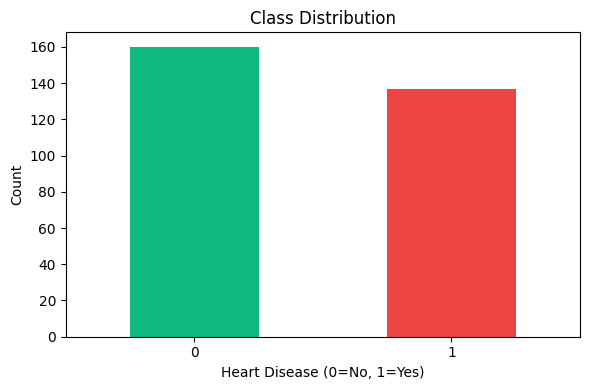

In [ ]:
plt.figure(figsize=(6, 4))
df['Heart_disease'].value_counts().plot(kind='bar', color=['#10b981', '#ef4444'])
plt.title('Class Distribution')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
df.describe()

,Age,Sex,Chest_pain,Resting_blood_pressure,Cholesterol,Fasting_Blood_Sugar,ECG_results,Maximum_heart_rate,Exercise_induced_angina,ST_depression,ST_slope,Major_vessels,Thalassemia_types,Heart_disease
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.619408,246.809235,0.144781,0.996633,149.641414,0.326599,1.046491,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.511403,49.466386,0.352474,0.994914,22.807957,0.469761,1.132816,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,83.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,184.982022,417.000000,1.000000,2.000000,202.000000,1.000000,4.553924,3.000000,3.000000,7.000000,1.000000


## Step 3 — Feature / Target Split

We separate the dataset into:
- **X** — the 13 input features the model learns from
- **y** — the target label (Heart_disease) the model tries to predict

This is standard ML practice. The model never sees y during training — it only sees X and tries to predict y.

Features shape: (297, 13)
Target shape:   (297,)
Feature names:  ['Age', 'Sex', 'Chest_pain', 'Resting_blood_pressure', 'Cholesterol', 'Fasting_Blood_Sugar', 'ECG_results', 'Maximum_heart_rate', 'Exercise_induced_angina', 'ST_depression', 'ST_slope', 'Major_vessels', 'Thalassemia_types']


In [ ]:
# X = all columns except the target
# y = the target column (Heart_disease)
X = df.drop('Heart_disease', axis=1)
y = df['Heart_disease']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'Feature names:  {list(X.columns)}')

## Step 4 — Train / Test Split

We split the data into two sets:
- **80% Training** (237 samples) — used to train the model
- **20% Testing** (60 samples) — held out to evaluate real-world performance

stratify=y ensures both splits have the same class ratio (important for imbalanced datasets).

> The model **never sees the test set during training** — this gives us an honest accuracy score.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 237
Testing samples:  60


## Step 5 — Feature Scaling

Most ML algorithms perform better when all features are on the same scale.

We use **StandardScaler** which transforms each feature to have:
- Mean = 0
- Standard Deviation = 1

**Important rule:** We it_transform on training data only, then 	ransform the test data using the same parameters. Fitting on test data would be **data leakage** — the model would be cheating by peeking at test statistics.

In [8]:

scaler = StandardScaler()

# fit_transform on training data: learns the mean/std AND transforms
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test data: uses the SAME mean/std from training
# (never fit on test data Ã¢â‚¬â€ that would be data leakage)
X_test_scaled = scaler.transform(X_test)

print('Scaling complete.')
print(f'Example Ã¢â‚¬â€ Age column before scaling: {X_train["Age"].mean():.1f} mean')
print(f'Example Ã¢â‚¬â€ Age column after scaling:  {X_train_scaled[:, 0].mean():.4f} mean (should be ~0)')

Scaling complete.
Example Ã¢â‚¬â€ Age column before scaling: 54.8 mean
Example Ã¢â‚¬â€ Age column after scaling:  -0.0000 mean (should be ~0)


## Step 6 — Build the Stacking Ensemble

Instead of using a single model, we use a **Stacking Ensemble** — a powerful technique that combines multiple models.

**Architecture:**
``nLevel 0 (Base Models):
  ├── Logistic Regression
  ├── Random Forest (100 trees)
  └── XGBoost

Level 1 (Meta-Learner):
  └── Logistic Regression (learns from base model predictions)
`

**Why stacking?** Each base model captures different patterns. The meta-learner then learns the best way to combine their predictions — resulting in higher accuracy than any single model alone.

In [9]:
# --- Base Models (Level 0) ---

base_models = [
    ('logistic_regression', LogisticRegression(
        max_iter=1000,
        random_state=42
    )),
    ('random_forest', RandomForestClassifier(
        n_estimators=100,   
        random_state=42
    )),
    ('xgboost', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ))
]

# --- Meta-Learner (Level 1) ---

meta_learner = LogisticRegression(max_iter=1000, random_state=42)


stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False 
)

print('Stacking ensemble built.')
print('Base models: Logistic Regression, Random Forest, XGBoost')
print('Meta-learner: Logistic Regression')

Stacking ensemble built.
Base models: Logistic Regression, Random Forest, XGBoost
Meta-learner: Logistic Regression


## Step 7 — Train the Model

We fit the stacking ensemble on the scaled training data.

Internally, sklearn uses **5-fold cross-validation** to train the base models, so the meta-learner is trained on out-of-fold predictions. This prevents the meta-learner from overfitting to the training data.

> This step takes 30–60 seconds depending on your machine.

In [10]:
print('Training stacking ensemble... (this takes 30-60 seconds)')

stacking_model.fit(X_train_scaled, y_train)

print('Training complete!')

Training stacking ensemble... (this takes 30-60 seconds)
Training complete!


## Step 8 — Evaluate Performance

We evaluate the model on the **held-out test set** (data the model has never seen).

**Metrics explained:**
- **Accuracy** — % of correct predictions overall
- **ROC-AUC** — measures how well the model separates the two classes (1.0 = perfect, 0.5 = random)
- **Precision** — of all predicted Disease cases, how many were actually Disease?
- **Recall** — of all actual Disease cases, how many did we catch?
- **F1-Score** — harmonic mean of Precision and Recall

**Threshold = 0.4** (not 0.5) — we use a lower threshold because in medical diagnosis, missing a real disease case (false negative) is more dangerous than a false alarm.

In [11]:
# Predict on test set
# Using threshold 0.4 (same as app.py) Ã¢â‚¬â€ more sensitive for medical use
THRESHOLD = 0.4

y_prob  = stacking_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1
y_pred  = (y_prob >= THRESHOLD).astype(int)                  # apply threshold

# Core metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print('=' * 40)
print(f'  Accuracy:  {accuracy * 100:.2f}%')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print('=' * 40)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

  Accuracy:  85.00%
  ROC-AUC:   0.9453

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.85      0.88      0.86        32
     Disease       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



========================================
  Accuracy:  85.00%
  ROC-AUC:   0.9453
========================================

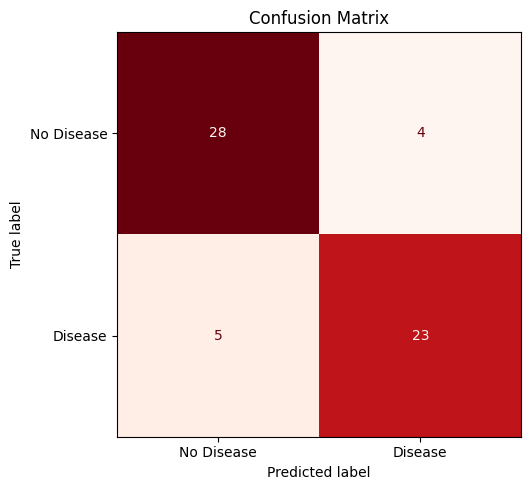

In [12]:
# Confusion Matrix
# Shows: True Positives, True Negatives, False Positives, False Negatives
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Reds')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [13]:
# Cross-validation score (more reliable than single train/test split)
# Tests the model on 5 different splits of the data
cv_scores = cross_val_score(
    stacking_model, X_train_scaled, y_train,
    cv=5, scoring='accuracy'
)

print(f'Cross-validation scores: {cv_scores.round(4)}')
print(f'Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%')
print(f'Std Dev:          {cv_scores.std() * 100:.2f}%')

Cross-validation scores: [0.9583 0.9167 0.8298 0.7234 0.7234]
Mean CV Accuracy: 83.03%
Std Dev:          9.66%


## Step 9 — Feature Importance

We extract feature importance scores from the **Random Forest** base model inside the stacking ensemble.

This tells us which features had the most influence on predictions.

**Top features typically are:**
1. Chest_pain — type of chest pain is a strong cardiac indicator
2. Thalassemia_types — blood disorder linked to heart disease
3. Maximum_heart_rate — lower max HR often indicates heart problems
4. ST_depression — ECG reading during exercise
5. Major_vessels — number of major vessels coloured by fluoroscopy

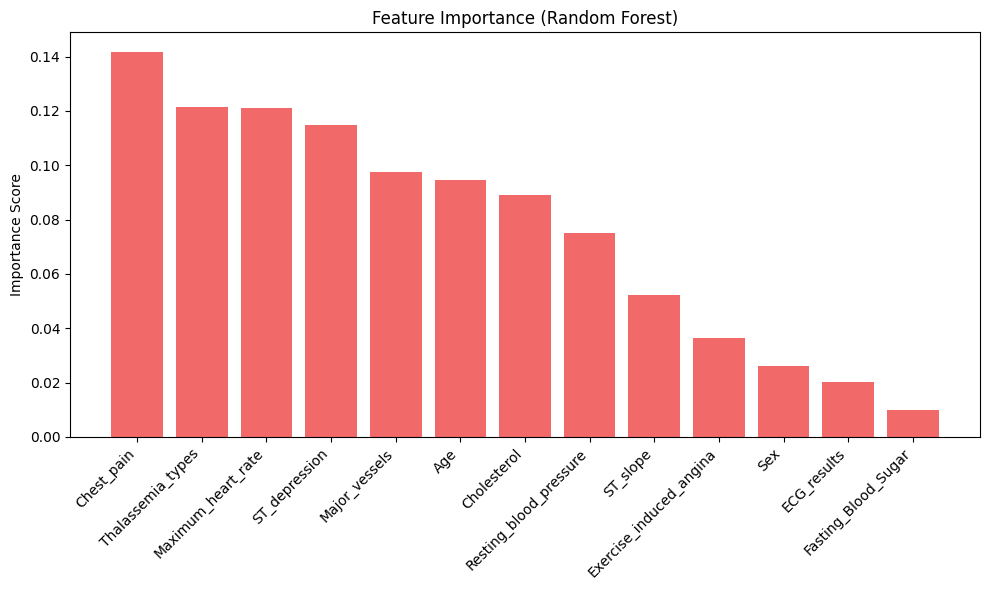

Top 5 most important features:
  1. Chest_pain: 0.1419
  2. Thalassemia_types: 0.1216
  3. Maximum_heart_rate: 0.1211
  4. ST_depression: 0.1148
  5. Major_vessels: 0.0976


In [14]:

rf_model = stacking_model.named_estimators_['random_forest']
feature_names = list(X.columns)
importances = rf_model.feature_importances_


indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), importances[indices], color='#ef4444', alpha=0.8)
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for i in range(5):
    print(f'  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}')

In [15]:
# Save the scaler Ã¢â‚¬â€ app.py needs this to normalize user input before prediction
joblib.dump(scaler, 'models/scaler.pkl')
print('Saved: scaler.pkl')

# Save the trained stacking model Ã¢â‚¬â€
joblib.dump(stacking_model, 'models/stacking_ensemble_heart_disease.pkl')
print('Saved: stacking_ensemble_heart_disease.pkl')

print()
print('Both files saved. ')

Saved: scaler.pkl
Saved: stacking_ensemble_heart_disease.pkl

Both files saved. 


In [16]:


loaded_model  = joblib.load('models/stacking_ensemble_heart_disease.pkl')
loaded_scaler = joblib.load('models/scaler.pkl')

# Sample patient data (same format as the form in app.py)
# age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
sample = np.array([[63, 1, 1, 145, 233, 1, 2, 150, 0, 2.3, 3, 0, 6]])

sample_scaled = loaded_scaler.transform(sample)
prob = loaded_model.predict_proba(sample_scaled)[0][1]
prediction = int(prob >= 0.4)

print(f'Test prediction:')
print(f'  Risk probability: {prob * 100:.2f}%')
print(f'  Prediction:       {"High Risk" if prediction == 1 else "Low Risk"}')
print()
print('Model verified.')

Test prediction:
  Risk probability: 19.55%
  Prediction:       Low Risk

Model verified.
